<center>
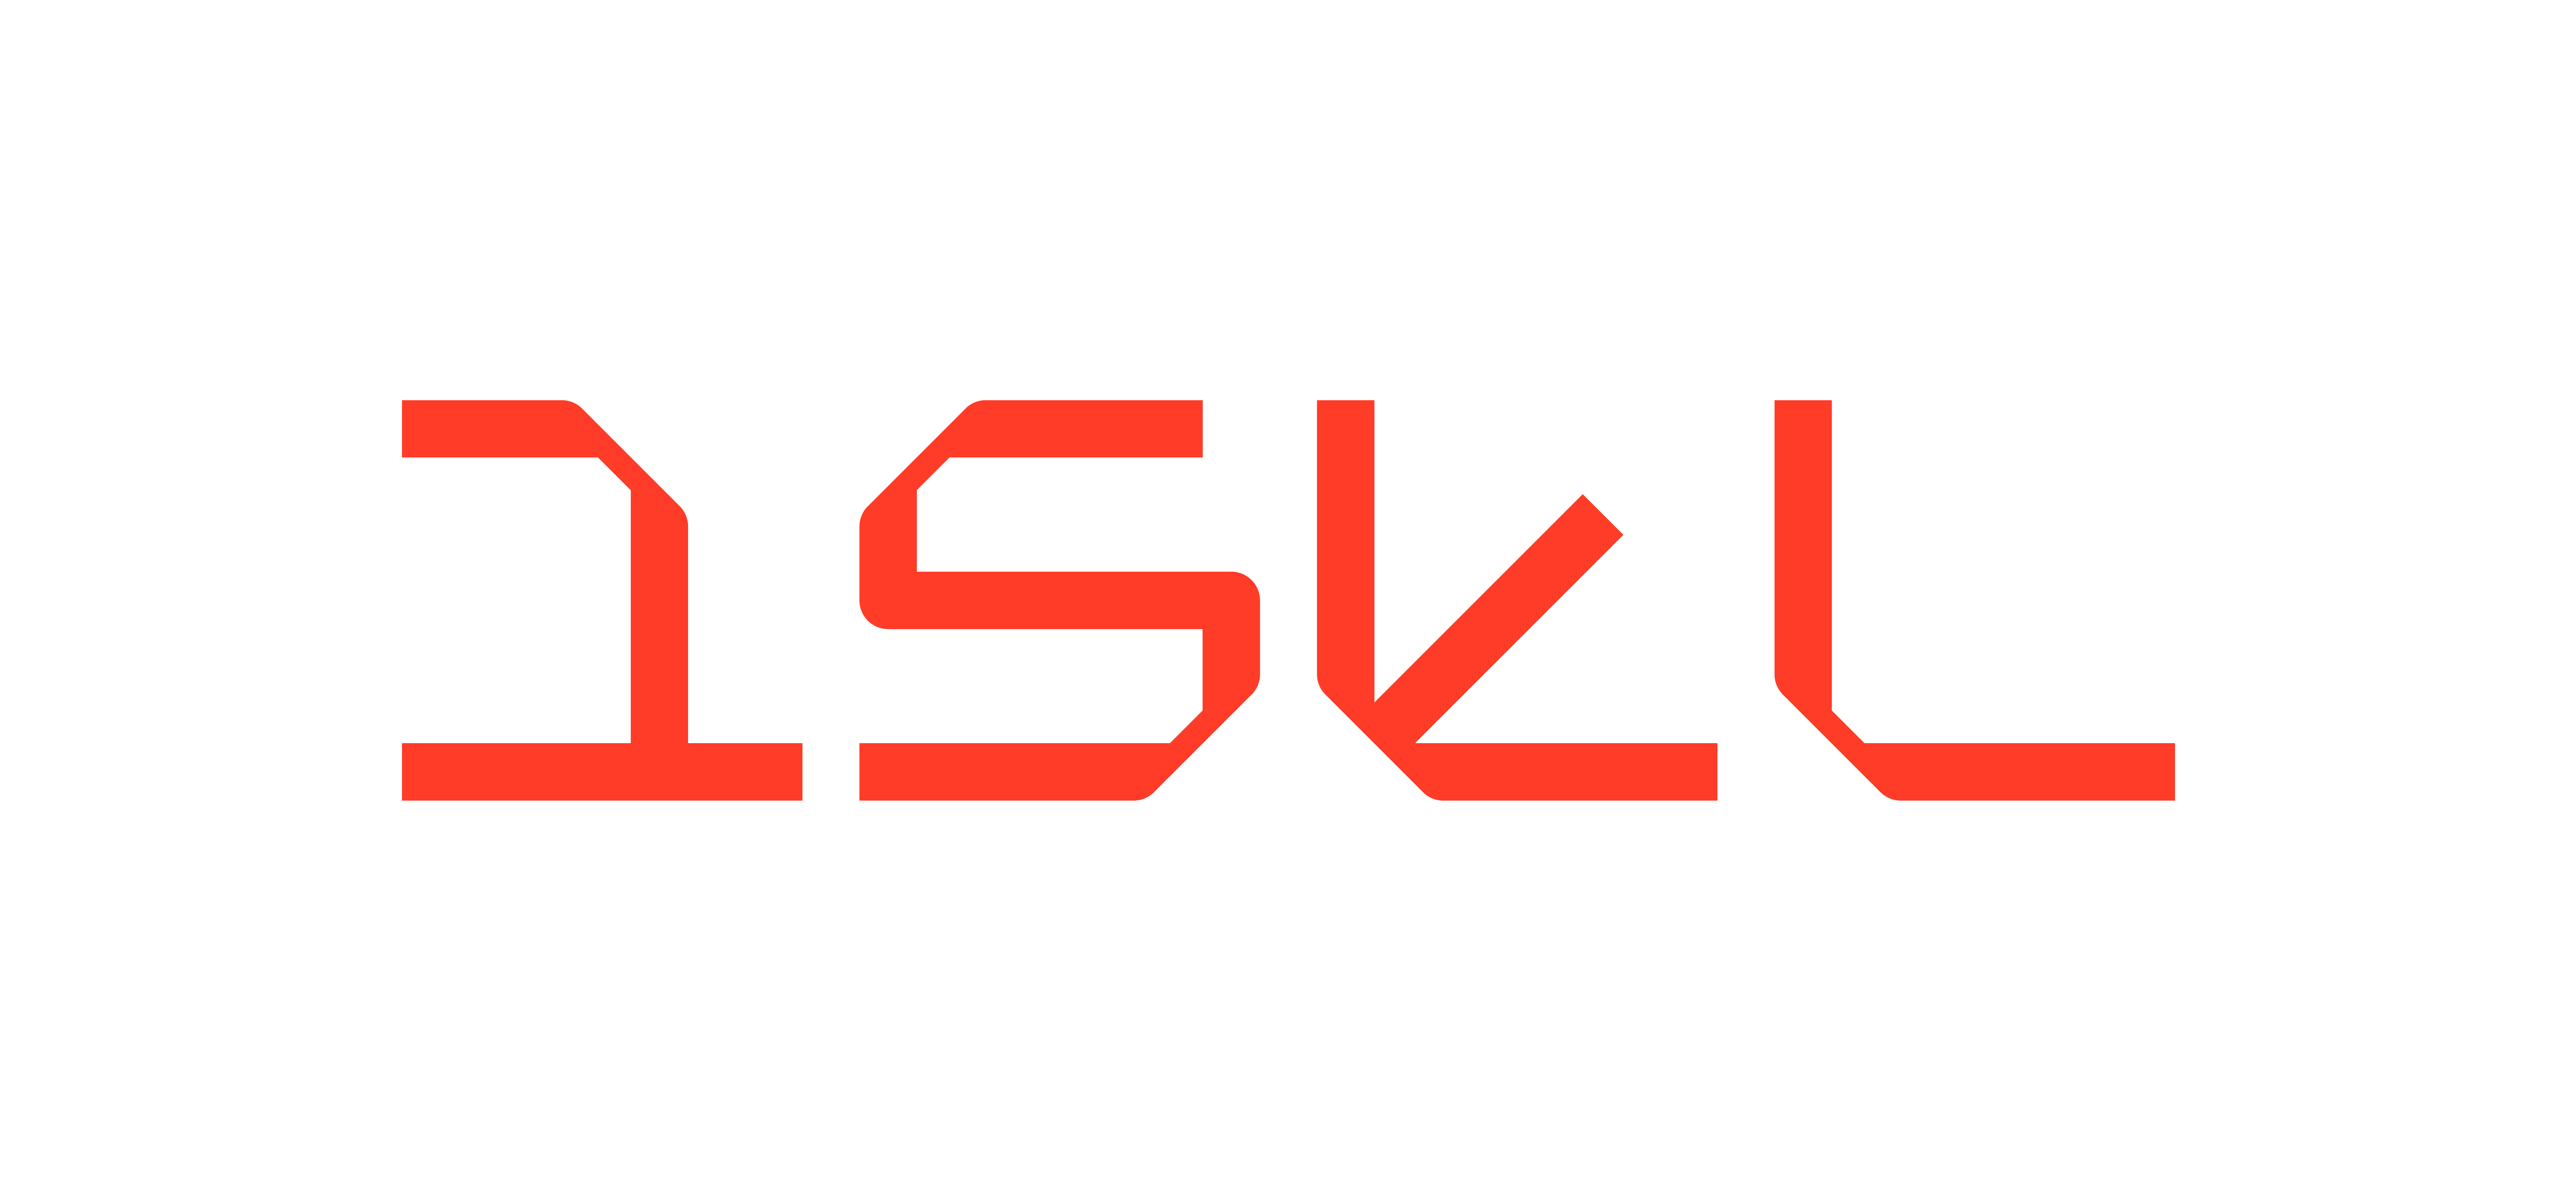
</center>

## <center><b>Instituto Superior de Engenharia de Lisboa<b></center>
### <center>Licenciatura em Engenharia Informática e Multimédia</center>
### <center><b>Processamento de Imagem e Visão</b><br>1º Semestre de 2025/2026</center>
#### <center><b>Trabalho Práctico 2</b></center>

<a id="inicio"></a>

<hr>
<br>
<center>Trabalho realizado por:<br>
• 46346 Inês Silva<br>
• 50274 Joana Araújo </center>
<br>

<br>

<center><b>Turma 51N ▪ Docente Nuno Silva</b></center><br>
<hr>

In [2]:
# importação das bibliotecas

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
#from collections import Counter
from scipy.spatial import distance as dist
#from collections import OrderedDict
import time
import random
import ctypes
import pygame

pygame 2.6.1 (SDL 2.28.4, Python 3.13.7)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
folder = "assets/media/"
folderXML = "assets/xml/"
frame_test = cv.imread(folder + "img_teste_4.png")

In [4]:
# Som da bola
pygame.mixer.init()
pop_som = pygame.mixer.Sound(folder + "pop.mp3")

In [5]:
# Capturar um frame da webcam para experiência

#cap = cv.VideoCapture(0)
ret, frame_test = cap.read()
cap.release()

if ret:
    # Espelha o frame para ser mais intuitivo
    frame_test = cv.flip(frame_test, 1)  
    print(f"Frame capturado: {frame_test.shape}")
    
    plt.figure(figsize=(10, 6))
    plt.imshow(cv.cvtColor(frame_test, cv.COLOR_BGR2RGB))
    plt.title("Frame Original de Teste")
    plt.axis('off')
    plt.show()
else:
    print("Erro ao capturar frame da webcam")

NameError: name 'cap' is not defined

In [6]:
class Config:
    try:
        # Tenta obter resolução do Windows com DPI Aware
        user32 = ctypes.windll.user32
        user32.SetProcessDPIAware()
        _screen_w = user32.GetSystemMetrics(0)
        _screen_h = user32.GetSystemMetrics(1)
        
        # Define o tamanho da janela com margem
        WINDOW_WIDTH = _screen_w - 75
        WINDOW_HEIGHT = _screen_h - 100
    except:
        # Fallback para Linux/Mac ou erro
        WINDOW_WIDTH = 1280
        WINDOW_HEIGHT = 720

    # Parâmetros de Jogo
    GAME_WIDTH = WINDOW_WIDTH
    GAME_HEIGHT = WINDOW_HEIGHT
    GAME_DURATION = 10
    
    # Parâmetros de Visão
    MIN_CONTOUR_AREA = 2000
    
    # Ranges YCrCb para pele (Luminância, Vermelho-Diferença, Azul-Diferença)
    SKIN_YCRCB_LOWER = np.array([0, 133, 77], dtype=np.uint8)
    SKIN_YCRCB_UPPER = np.array([255, 173, 127], dtype=np.uint8)
    
    # Ranges HSV para pele (Tonalidade, Saturação, Valor)
    SKIN_HSV_LOWER = np.array([0, 20, 70], dtype=np.uint8)
    SKIN_HSV_UPPER = np.array([20, 255, 255], dtype=np.uint8)
    
    # Kernels Morfológicos
    KERNEL_ELLIPSE_5 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
    KERNEL_ELLIPSE_15 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (15, 15))

In [7]:
class VirtualBall:
    def __init__(self, x, y, radius=30, color=(0, 255, 255), tipo="normal"):
        self.x = x
        self.y = y
        self.vx = random.randint(-5, 5)
        self.vy = random.randint(-5, 5)
        self.radius = radius
        self.color = color
        self.active = True
        self.tipo = tipo
        # adicao de um tipo diferente de VirtualBall, com dobro dos pontos
        if tipo == "normal":
            self.color = (0, 255, 255)
            self.points = 1
        elif tipo == "especial":
            self.color = (225, 73, 57)
            self.points = 2
        self.active = True

        # bolas especiais tem alguns segundos ate desaparecerem
        self.lifetime = random.randint(4,5)  if tipo == "especial" else None
        self.spawn_time = time.time()
        
    # animacao de rebentar
        self.popping = False
        self.pop_frame = 0
        self.max_pop_frames = 8

    def expired(self):
        if self.tipo == "especial":
            tempo = time.time() - self.spawn_time
            print(str(tempo) + " " + str(self.lifetime))
            if tempo >= self.lifetime :
                self.popping = True
                return True
        return False
        
    def start_pop(self):
        self.popping = True
        self.pop_frame = 0

    def draw_pop(self, frame):
        if not self.popping:
            return False
        self.active = False
        progresso = self.pop_frame / self.max_pop_frames

        # raio aumenta e transparencia diminui conforme frame
        pop_radius = int(self.radius * (1. + progresso * 0.8))
        opacity = max(0, 1.0 - progresso)

        frame_new = frame.copy()
        cv.circle(frame_new, (self.x, self.y), pop_radius, self.color, 2)
        
        cv.addWeighted(frame_new, opacity, frame, 1 - opacity, 0, frame)

        self.pop_frame += 1
        return self.pop_frame < self.max_pop_frames
        
    def update(self, width, height):
        if not self.active: return
        self.x += self.vx
        self.y += self.vy
        if self.x - self.radius < 0 or self.x + self.radius > width: self.vx *= -1
        if self.y - self.radius < 0 or self.y + self.radius > height: self.vy *= -1

    def draw(self, frame):
              
        if self.active and not self.popping:
            cv.circle(frame, (int(self.x), int(self.y)), self.radius, self.color, -1)
            cv.circle(frame, (int(self.x), int(self.y)), self.radius, (0,0,0), 2)
        else:
            # Animacao de rebentar
            still_animating = self.draw_pop(frame)
            if not still_animating:
                self.popping = False

    def check_collision_with_point(self, point, collision_radius=60):
        if not self.active: return False
        px, py = point
        dist = np.sqrt((self.x - px)**2 + (self.y - py)**2)
        
        if dist < self.radius + collision_radius:
            self.popping = True
            return True
        return False

In [8]:
def get_contour_features(cnt, frame_height):
    """
    Função get_contour_features()

    Extrai características geométricas avançadas de um contorno, incluindo a deteção de pontas de dedos.
    Realiza a análise topológica do contorno para identificar mãos e dedos.
    Aplica suavização (approxPolyDP), calcula o invólucro convexo (Convex Hull) e analisa 
    os defeitos de convexidade. Utiliza filtros de profundidade relativa e ângulos 
    (Lei dos Cossenos) para validar se os defeitos correspondem a espaços entre dedos.

    Args:
        cnt:            array de pontos com os contornos
        frame_height:   A altura total da imagem/frame em pixéis.

    Returns:
        dict | None:    Retorna um dicionário com as características extraídas se o contorno for válido, 
                        ou None se a área for zero ou o contorno for demasiado pequeno.
    """
    if (area := cv.contourArea(cnt)) == 0: 
        return None
    
    x, y, w, h = cv.boundingRect(cnt)
    M = cv.moments(cnt)
    cx = int(M["m10"] / M["m00"]) if M["m00"] != 0 else 0
    cy = int(M["m01"] / M["m00"]) if M["m00"] != 0 else 0

    if (perimeter := cv.arcLength(cnt, True)) == 0: 
        return None
    
    epsilon = 0.01 * perimeter 
    approx = cv.approxPolyDP(cnt, epsilon, True)
    hull = cv.convexHull(approx, returnPoints=False)
    
    defects_count = 0
    fingertips = []
    topmost = tuple(cnt[cnt[:, :, 1].argmin()][0])
    fingertips.append(topmost)

    if len(hull) > 3 and len(approx) > 3:
        try:
            if (defects := cv.convexityDefects(approx, hull)) is not None: 
                d = defects[:, 0, :]
                
                start_idx, end_idx, far_idx, depth_fix = d[:, 0], d[:, 1], d[:, 2], d[:, 3]
                
                depths = depth_fix / 256.0
                min_depth = max(5, frame_height * 0.05)
                mask_depth = depths > min_depth
                
                if np.any(mask_depth):
                    pts_start = approx[start_idx[mask_depth]][:, 0] # shape (M, 2)
                    pts_end = approx[end_idx[mask_depth]][:, 0]
                    pts_far = approx[far_idx[mask_depth]][:, 0]
                    
                    a = np.linalg.norm(pts_end - pts_start, axis=1)
                    b = np.linalg.norm(pts_far - pts_start, axis=1)
                    c = np.linalg.norm(pts_end - pts_far, axis=1)
                    
                    cos_angle = (b**2 + c**2 - a**2) / (2 * b * c + 1e-7)
                    angles = np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))
                    
                    mask_angle = angles <= 100
                    
                    defects_count = np.sum(mask_angle)
                    
                    if defects_count > 0:
                        valid_starts = pts_start[mask_angle]
                        valid_ends = pts_end[mask_angle]
                        for pt in valid_starts: fingertips.append(tuple(pt))
                        for pt in valid_ends: fingertips.append(tuple(pt))
                        
                        fingertips = list(set(fingertips)) 
        except Exception as e:
            print(f"Ocorreu um erro: {e}")

    return {
        'cnt': approx, 'area': area, 'defects': defects_count, 
        'fingertips': fingertips, 'bbox': (x, y, w, h), 'center': (cx, cy)
    }

In [9]:
class RegionDetector:
    def __init__(self):
        # Carregar Haar Cascade
        path = folderXML + 'haarcascade_frontalface_default.xml'
        self.face_cascade = cv.CascadeClassifier(path)
    
    def _detect_head(self, frame, mask):
            """
            Deteta a cabeça usando Haar Cascade e remove-a da máscara.
            Retorna: (dados_cabeça, máscara_sem_cabeça)
            """
            h, w = frame.shape[:2]
            mask_body = mask.copy() 
            head_data = None

            gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
            faces = self.face_cascade.detectMultiScale(gray, 1.1, 5)

            if len(faces) > 0:
                areas = faces[:, 2] * faces[:, 3] # largura * altura
                largest_idx = np.argmax(areas)
                fx, fy, fw, fh = faces[largest_idx]

                # Expandir caixa (Incluir testa e orelhas)
                infl_w = int(fw * 0.2)
                infl_h_top = int(fh * 0.4)
                
                # np.clip garante que não saímos da imagem (substitui os max/min manuais)
                nx = np.clip(fx - infl_w, 0, w)
                ny = np.clip(fy - infl_h_top, 0, h)
                nx2 = np.clip(fx + fw + infl_w, 0, w)
                ny2 = np.clip(fy + fh + int(fh * 0.3), 0, h)
                
                nw, nh = nx2 - nx, ny2 - ny

                head_data = {
                    'center': (int(nx + nw//2), int(ny + nh//2)),
                    'bbox': (int(nx), int(ny), int(nw), int(nh))
                }

                # "Cortar" a cabeça da máscara (pintar de preto)
                cv.rectangle(mask_body, (int(nx), int(ny)), (int(nx2), int(ny2)), 0, -1)

            return head_data, mask_body

    def _classify_limbs(self, mask_body, frame_shape):
        """
        Analisa os contornos restantes para encontrar mãos e pés.
        """
        h, w = frame_shape[:2]
        hands = []
        feet = []

        contours, _ = cv.findContours(mask_body, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

        for cnt in contours:

            if cv.contourArea(cnt) < Config.MIN_CONTOUR_AREA: 
                continue

            feats = get_contour_features(cnt, h)
            if not feats: continue

            rel_y = feats['center'][1] / h
            
            if rel_y > 0.8:
                feet.append(feats)
            else:
                is_hand_size = feats['area'] < (w * h) * 0.15
                if feats['defects'] > 0 or is_hand_size:
                    hands.append(feats)

        return hands, feet

    def detect(self, mask, frame):
        """
        Função principal: Orquestra a deteção completa.
        """

        head, mask_body = self._detect_head(frame, mask)
        hands, feet = self._classify_limbs(mask_body, frame.shape)

        return {
            'head': head,
            'hands': hands,
            'feet': feet
        }

    def draw_debug(self, frame, regions):
        # Cabeça
        if regions['head']:
            x, y, w, h = regions['head']['bbox']
            cv.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 255), 2)
            cv.putText(frame, "HEAD", (x, y-10), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,255), 2)
        # Mãos
        for r in regions['hands']:
            cv.drawContours(frame, [r['cnt']], -1, (0, 255, 0), 2)
            for ft in r['fingertips']: # Pontos de colisão
                cv.circle(frame, ft, 5, (0, 0, 255), -1)
        # Pés
        for r in regions['feet']:
            x, y, w, h = r['bbox']
            cv.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
        return frame

In [10]:
class ImageProcessor:
    def __init__(self):
        self.backSub = cv.createBackgroundSubtractorMOG2(history=500, varThreshold=100, detectShadows=False)

    def get_foreground_mask(self, frame):
        """Detecta apenas o que se mexe (foreground)."""
        # Aplica a subtração
        fg_mask = self.backSub.apply(frame)
        
        # Limpeza morfológica para remover ruído da câmara
        kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
        fg_mask = cv.morphologyEx(fg_mask, cv.MORPH_OPEN, kernel)
        fg_mask = cv.morphologyEx(fg_mask, cv.MORPH_DILATE, kernel)
        
        return fg_mask

    def get_combined_mask(self, frame):
        """Combina Movimento + Pele para máxima robustez"""
        # 1. O que é que se mexe? (Ignora a parede creme estática)
        motion_mask = self.get_foreground_mask(frame)
        
        # 2. O que é que parece pele? (YCrCb + HSV)
        skin_mask = self.get_skin_mask(frame) # A tua função atual
        
        # Intersecção: Tem de se mexer e parecer pele
        final_mask = cv.bitwise_and(motion_mask, skin_mask)
        
        return final_mask

    @staticmethod
    def get_skin_mask(frame):
        """
        Segmentação Híbrida: YCrCb + HSV
        Remove o que não é pele com alta precisão.
        """
        # YCrCb (Luminância, Crominância)
        ycrcb = cv.cvtColor(frame, cv.COLOR_BGR2YCrCb)
        mask_ycrcb = cv.inRange(ycrcb, Config.SKIN_YCRCB_LOWER, Config.SKIN_YCRCB_UPPER)
        
        # HSV (Matiz, Saturação) - Ranges estritos para evitar amarelos
        hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
        mask_hsv = cv.inRange(hsv, Config.SKIN_HSV_LOWER, Config.SKIN_HSV_UPPER)
        
        # Combinar com AND (Interseção) -> Tem de ser pele em ambos os espaços
        mask_skin = cv.bitwise_and(mask_ycrcb, mask_hsv)
        
        # Limpeza Morfológica
        mask_clean = cv.morphologyEx(mask_skin, cv.MORPH_CLOSE, Config.KERNEL_ELLIPSE_5, iterations=3)
        mask_clean = cv.morphologyEx(mask_clean, cv.MORPH_OPEN, Config.KERNEL_ELLIPSE_5, iterations=2)
        
        # Dilatar para consolidar o corpo
        mask_final = cv.dilate(mask_clean, Config.KERNEL_ELLIPSE_15, iterations=2)
        
        return mask_final

In [17]:
# ECRÃS JOGO

def game_main_menu(frame, mask, height):
    
    cv.putText(frame, "Pressione SPACE para comecar", (50, 100), cv.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv.putText(frame, "Modo: Detecao Auto de Pele", (50, 150), cv.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 1)

    thumb_mask = cv.resize(mask, (160, 120))
    thumb_mask = cv.cvtColor(thumb_mask, cv.COLOR_GRAY2BGR)

    start_y = height - 130
    end_y = height - 10

    if start_y > 0:
        frame[start_y:end_y, 10:170] = thumb_mask
        cv.putText(frame, "Mask Debug", (10, height-135), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

def game_draw_hud(frame, score, remaining_time, width):
    """
    Desenha Heads Up Display apenas com o texto da pontuação e tempo.
    """
    cv.putText(frame, f"Score: {score}", (30, 50), cv.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv.putText(frame, f"Time: {remaining_time}", (width - 200, 50), cv.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)

def game_over_menu(frame, score, width, height):
    """
    Desenha Overlay para o GameOver com o texto da pontuação e indicação para reiniciar.
    """
    cv.putText(frame, "GAME OVER", (width//2-120, height//2), cv.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 3)
    cv.putText(frame, f"Final Score: {score}", (width//2-120, height//2+60), cv.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    cv.putText(frame, "Press R to Restart", (width//2-120, height//2+120), cv.FONT_HERSHEY_SIMPLEX, 0.8, (200, 200, 200), 2)

In [ ]:
# LÓGICA JOGO

def update_game_logic(balls, width, height, regions, current_score, pop_som):
    """
    Trata da física, colisões e gestão de bolas.
    Retorna: O score atualizado.
    """
    balls_to_remove = []
    
    # 1. Atualizar e Verificar Colisões
    for ball in balls:
        ball.update(width, height)
        
        if ball.active:
            hit = False
            # Verificar colisão com mãos
            for hand in regions['hands']:
                fingertips = hand.get('fingertips', [])
                points = [hand['center']] + fingertips
                
                for pt in points:
                    radius = 60 if pt == hand['center'] else 30
                    if ball.check_collision_with_point(pt, radius):
                        if pop_som: pop_som.play()
                        hit = True
                        break
                if hit: break
            
            if hit: 
                current_score += 1
        
        # Se expirou ou foi atingida
        if ball.expired() or (not ball.active):
            balls_to_remove.append(ball)

    # 2. Remover Bolas (Gestão de memória)
    for ball in balls_to_remove:
        if ball in balls:
            balls.remove(ball)
            # Respawn imediato (opcional, para manter fluxo)
            tipo = random.choices(["normal", "especial"], weights=[0.8, 0.2])[0]
            balls.append(VirtualBall(random.randint(50, width-50), 
                                     random.randint(50, height-50), tipo=tipo))

    # 3. Repor se vazio
    if len(balls) == 0:
         for _ in range(5):
             tipo = random.choices(["normal", "especial"], weights=[0.8, 0.2])[0]
             balls.append(VirtualBall(random.randint(50, width-50), 
                                      random.randint(50, height-50), tipo=tipo))
                                      
    return current_score

In [16]:
class GameApp:
    def __init__(self):
        self.cap = cv.VideoCapture(0)
            
        cv.namedWindow("Game", cv.WINDOW_NORMAL)
        cv.resizeWindow("Game", Config.WINDOW_WIDTH, Config.WINDOW_HEIGHT)
        
        self.width = int(self.cap.get(cv.CAP_PROP_FRAME_WIDTH))
        self.height = int(self.cap.get(cv.CAP_PROP_FRAME_HEIGHT))
        
        self.detector = RegionDetector()
        self.processor = ImageProcessor()
        self.prev_hand_centers = []

        self.state = "MENU" # MENU, GAME, GAMEOVER
        self.balls = []
        self.score = 0
        self.start_time = 0

    def draw_motion_vectors(self, frame, current_regions):
            """
            Calcula e desenha vetores de movimento usando NumPy (Broadcasting).
            """
            current_centers = [r['center'] for r in current_regions['hands']]
            
            if self.prev_hand_centers and current_centers:
                
                curr = np.array(current_centers)
                prev = np.array(self.prev_hand_centers)
                
                diffs = curr[:, np.newaxis, :] - prev[np.newaxis, :, :]          
                dists = np.linalg.norm(diffs, axis=2)            
                nearest_indices = np.argmin(dists, axis=1)
                min_dists = dists[np.arange(len(dists)), nearest_indices]
                
                for i, dist in enumerate(min_dists):
                    if 2 < dist < 150:
                        pt_curr = tuple(curr[i])
                        pt_prev = tuple(prev[nearest_indices[i]])
                        cv.arrowedLine(frame, pt_prev, pt_curr, (0, 0, 255), 3, tipLength=0.3)

            self.prev_hand_centers = current_centers
            
            return frame

    def start_game(self):
        self.state = "GAME"
        self.score = 0
        self.start_time = time.time()
        self.balls = [VirtualBall(random.randint(50, self.width-50), random.randint(50, self.height-50)) for _ in range(5)]

    def run(self):
        while True:
            ret, frame = self.cap.read()
            if not ret: break
            frame = cv.flip(frame, 1)
            key = cv.waitKey(1)

            mask = self.processor.get_skin_mask(frame)       
            regions = self.detector.detect(mask, frame)
            frame = self.detector.draw_debug(frame, regions)
            frame = self.draw_motion_vectors(frame, regions)

            # Lógica de Jogo
            if self.state == "MENU":
                game_main_menu(frame, mask, self.height)

                if key == 32: self.start_game()
                elif key == ord('q'): break

            elif self.state == "GAME":
                remaining = Config.GAME_DURATION - int(time.time() - self.start_time)
                if remaining <= 0: self.state = "GAMEOVER"
                
                self.score = update_game_logic(self.balls, self.width, self.height, regions, self.score, pop_som)
                
                for ball in self.balls:
                    ball.draw(frame)

                game_draw_hud(frame, self.score, remaining, self.width)
                
            elif self.state == "GAMEOVER":
                game_over_menu(frame, self.score, self.width, self.height)
                
                if key == ord('r'): self.start_game()
                elif key == ord('q'): break

            cv.imshow("Game", frame)
            if key == ord('q'): break
        
        self.cap.release()
        cv.destroyAllWindows()

In [20]:
if __name__ == "__main__":
    app = GameApp()
    app.run()

### <center>**Conclusão**</center> <a class="anchor" id="chapter11"></a>
